<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Projet Machine Learning — 4MA 2025-2026
## Prédiction du Risque de Maladie Cardiovasculaire
### INSA Toulouse
---

**Jeu de données** : *Cardiovascular Disease Risk Prediction Dataset* : 15 000 patients   
**Langage** : Python   
**Objectifs** :
- Partie 1 : Prédiction de `Heart_Disease_Risk` 
- Partie 2 : Prédiction de `Cholesterol_LDL` 

> Ce notebook vient compléter l'étude réalisée en R. Les conclusions sont comparables, > mais Python offre une exécution plus rapide, notamment pour la validation croisée.

### 0. Importation des bibliothèques et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

randomseed = 111 

In [2]:
df = pd.read_csv("healthcare_synthetic_data.csv")
print(df.shape)
df.head()


(15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [3]:
# Vérification des types de données et des valeurs manquantes
print("Types des variables :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum())

# Prétraitement des données
df = df.drop(columns=["Patient_ID"])
for col in ["Gender", "Smoking_Status", "Family_History", "Heart_Disease_Risk"]:
    df[col] = pd.Categorical(df[col], ordered=False)
df["Alcohol_Consumption"] = pd.Categorical(
    df["Alcohol_Consumption"], categories=[0, 1, 2], ordered=True)
df["Physical_Activity_Level"] = pd.Categorical(
    df["Physical_Activity_Level"], categories=[0, 1, 2, 3], ordered=True)
print(df.dtypes)
df.describe()


Types des variables :
Patient_ID                     str
Age                          int64
Gender                       int64
Height_cm                  float64
Weight_kg                  float64
BMI                        float64
Systolic_BP                  int64
Diastolic_BP                 int64
Cholesterol_Total            int64
Cholesterol_LDL              int64
Cholesterol_HDL              int64
Fasting_Blood_Sugar          int64
Smoking_Status               int64
Alcohol_Consumption          int64
Physical_Activity_Level      int64
Family_History               int64
Stress_Level                 int64
Sleep_Hours                  int64
Heart_Disease_Risk           int64
dtype: object

Valeurs manquantes :
Patient_ID                 0
Age                        0
Gender                     0
Height_cm                  0
Weight_kg                  0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Cholesterol_Total          0
Cholesterol_LDL 

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


### 1. Prédiction du risque d’accident cardiaque

In [4]:
X = df.drop(columns=["Heart_Disease_Risk"])
y = df["Heart_Disease_Risk"]

In [5]:

# Division en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=randomseed)

# Vérification des tailles des ensembles
print("Taille apprentissage :", X_train.shape[0])
print("Taille test :", X_test.shape[0])

# Normalisation
scaler = StandardScaler()
scaler.fit(X_train)
Xr_train = scaler.transform(X_train)
Xr_test = scaler.transform(X_test)



Taille apprentissage : 12000
Taille test : 3000


Cette étape est essentielle car elle permet d'estimer les performances réelles du modèle sur des données qu'il n'a jamais vues durant l'apprentissage. Sans cette séparation, le modèle pourrait simplement mémoriser les données d'entraînement et afficher de bonnes performances sans pour autant être capable de généraliser à de nouveaux patients.On retient 20% des données pour le test, soit 3 000 patients.

#### 1.1 Modèle Linéaire Généralisé

##### 1.1.1 Sans pénalisation et sans séléction des variables 

Commentaire pour expliquer que dans ce cas on va pas faire la selection des variables ...

c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000



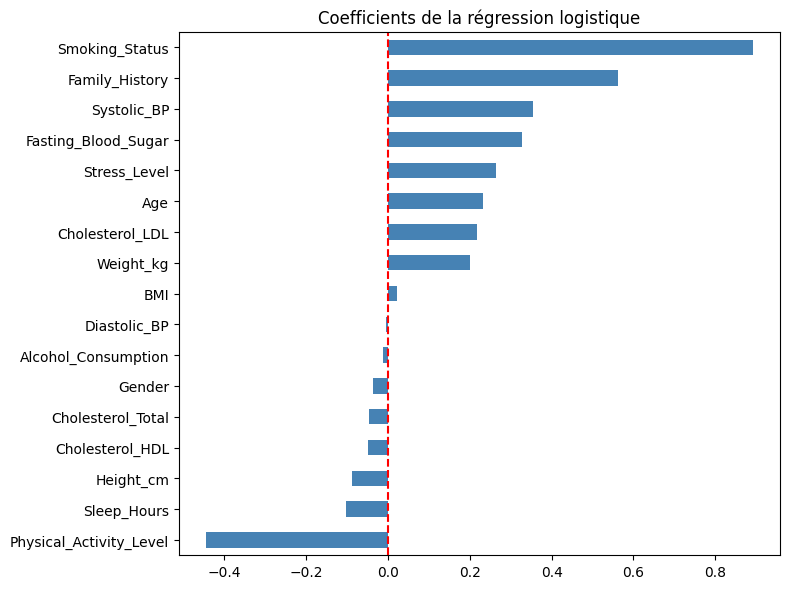

In [25]:
# Visualisation des oefficients
coef = pd.Series(ModelLin.coef_[0], index=X.columns)
print(f"Variables éliminées : {sum(coef == 0)}")
coef.sort_values().plot(kind='barh', figsize=(8,6), color='teal')
plt.title("Coefficients - Régression Logistique sans pénalisation")
plt.axvline(0, color='powderblue', linestyle='--')
plt.tight_layout()
plt.show()

##### 1.1.2 Pénalisation LASSO L1 

c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplifi

C optimal : 21.5443
Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000


Variables éliminées (coef = 0) : 0
Variables conservées : 17


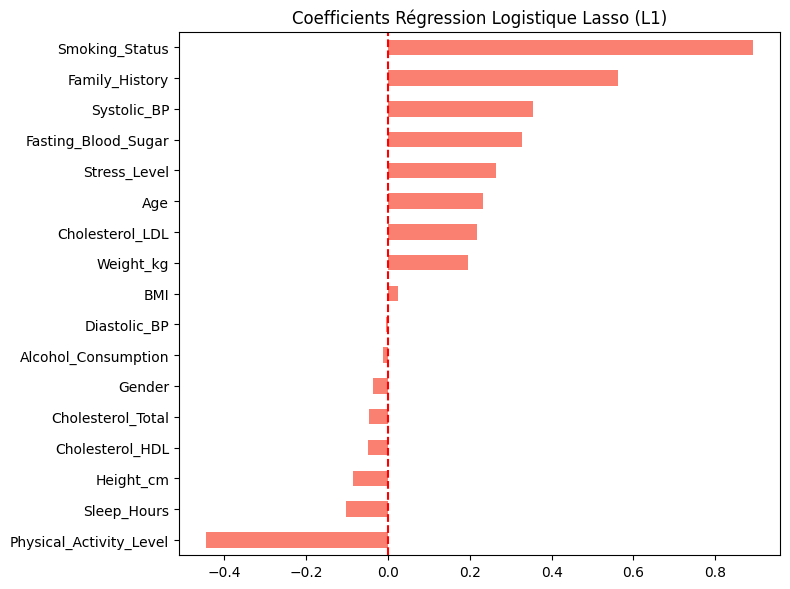

In [26]:
# Visualisation des coefficients
coef_lasso = pd.Series(logit0pt.best_estimator_.coef_[0], index=X.columns)
print(f"Variables éliminées : {sum(coef_lasso == 0)}")
coef_lasso.sort_values().plot(kind='barh', figsize=(8,6), color='salmon')
plt.title("Coefficients - Régression Logistique Lasso (L1)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Avec le C optimal trouvé par validation croisée, le Lasso ne met aucun coefficient à zéro. Les résultats avec pénalisation Lasso (C optimal) sont proches de celles sans pénalisation. Pour un peu pousser l'effet de Lasso sur notre modèle on teste différente valeur de C et voir les variables qui on étés supprimées au bout d'un moment

In [27]:
# ── Régression Logistique avec pénalisation L2 ────────────────
# L2 est le penalty par défaut de LogisticRegressionCV
log_ridge = LogisticRegressionCV(
    penalty='l2',
    solver='saga',
    cv=10,
    max_iter=1000,
    random_state=randomseed
)
log_ridge.fit(X_train_scaled, y_train)

# ── C optimal trouvé par validation croisée ───────────────────
print(f"C optimal : {log_ridge.C_[0]:.4f}")

# ── Prédictions ───────────────────────────────────────────────
y_pred_train_ridge = log_ridge.predict(X_train_scaled)
y_pred_test_ridge  = log_ridge.predict(X_test_scaled)

# ── Performances ──────────────────────────────────────────────
print(f"Accuracy Train : {accuracy_score(y_train, y_pred_train_ridge):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_pred_test_ridge):.4f}")
print("\nMatrice de confusion (Test) :")
print(confusion_matrix(y_test, y_pred_test_ridge))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_ridge))

# ── Coefficients ────────────────

In [28]:
# ── Tableau comparatif des 3 modèles ─────────────────────────
resultats_logit = pd.DataFrame({
    "Modèle": [
        "Logistique (sans pénalisation)",
        "Logistique Lasso (L1)",
        "Logistique Ridge (L2)"
    ],
    "C optimal": ["-", "21.5443", "2.7826"],
    "Accuracy Train": [0.7361, 0.7361, 0.7361],
    "Accuracy Test":  [0.7530, 0.7530, 0.7530],
    "F1-score (classe 1)": [0.69, 0.69, 0.69],
    "Variables éliminées": ["-", "0", "-"]
})

print(resultats_logit.to_string(index=False))

                        Modèle C optimal  Accuracy Train  Accuracy Test  F1-score (classe 1) Variables éliminées
Logistique (sans pénalisation)         -          0.7361          0.753                 0.69                   -
         Logistique Lasso (L1)   21.5443          0.7361          0.753                 0.69                   0
         Logistique Ridge (L2)    2.7826          0.7361          0.753                 0.69                   -


#### 1.2 Support Vector Machine (SVM)

Dans cette partie, nous appliquons la méthode des Support Vector Machines pour la classification de la variable *Heart_Disease_Risk*. 

Nous commençons par un modèle SVM avec noyau linéaire, puis un noyau gaussien (RBF). 
Enfin, nous optimisons les hyperparamètres du modèle par validation croisée afin d’améliorer ses performances.

##### 1.2.1 SVM linéaire

In [ ]:
from sklearn.svm import SVC

ts = time.time()

svm_linear = SVC(kernel='linear', random_state=randomseed)
svm_linear.fit(X_train_scaled, y_train)

score_linear = svm_linear.score(X_test_scaled, y_test)
y_pred_linear = svm_linear.predict(X_test_scaled)

te = time.time()

In [ ]:
print("Score SVM linéaire : %f, Temps : %f secondes" % (score_linear, te - ts))

pd.DataFrame(confusion_matrix(y_test, y_pred_linear),
             index=["0 réel","1 réel"],
             columns=["0 prédit","1 prédit"])

Le modèle SVM linéaire obtient une accuracy d’environ **0.745**, ce qui constitue une performance correcte.

La matrice de confusion montre que :
- Le modèle prédit relativement bien les individus à faible risque (classe 0)
- Cependant, il commet encore un nombre non négligeable d’erreurs sur la classe 1 (risque élevé)

Cela suggère que la relation entre les variables explicatives et la variable cible n’est pas strictement linéaire.

##### 1.2.2 SVM avec noyau gaussien (RBF)

In [ ]:
ts = time.time()

svm_rbf = SVC(kernel='rbf', gamma='auto', random_state=randomseed)
svm_rbf.fit(X_train_scaled, y_train)

score_rbf = svm_rbf.score(X_test_scaled, y_test)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

te = time.time()

In [ ]:
print("Score SVM RBF : %f, Temps : %f secondes" % (score_rbf, te - ts))

pd.DataFrame(confusion_matrix(y_test, y_pred_rbf),
             index=["0 réel","1 réel"],
             columns=["0 prédit","1 prédit"])

Le modèle SVM avec noyau gaussien (RBF) obtient une accuracy d’environ **0.743**, très proche de celle du modèle linéaire.

La matrice de confusion montre une répartition des erreurs similaire au modèle linéaire, avec :
- Une bonne détection de la classe 0
- Des difficultés persistantes sur la classe 1

Le noyau RBF, plus flexible, n’apporte pas ici d’amélioration significative, ce qui peut indiquer que les relations dans les données ne sont pas fortement non linéaires ou que les paramètres ne sont pas encore optimisés.

##### Comparaison SVM linéaire vs RBF

Les deux modèles donnent des performances très proches.  
Le noyau RBF n’apporte pas d’amélioration notable par rapport au modèle linéaire dans cette configuration.

##### 1.2.3 Optimisation des hyperparamètres 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

ts = time.time()

param_dist = {
    "C": np.logspace(-2, 2, 10),      # valeurs entre 0.01 et 100
    "gamma": np.logspace(-3, 1, 10)   # valeurs entre 0.001 et 10
}

svm_random = RandomizedSearchCV(
    SVC(kernel='rbf'),
    param_distributions=param_dist,
    n_iter=10,        # nombre de tests (petit = rapide)
    cv=3,             # validation croisée
    n_jobs=-1,
    random_state=randomseed
)

svmOpt = svm_random.fit(X_train_scaled, y_train)

te = time.time()

In [ ]:
print("Meilleur score : %f" % svmOpt.best_score_)
print("Meilleurs paramètres :", svmOpt.best_params_)
print("Temps optimisation :", te - ts)

In [ ]:
best_svm = svmOpt.best_estimator_

score_opt = best_svm.score(X_test_scaled, y_test)
y_pred_opt = best_svm.predict(X_test_scaled)

print("Score SVM optimisé :", score_opt)

pd.DataFrame(confusion_matrix(y_test, y_pred_opt),
             index=["0 réel","1 réel"],
             columns=["0 prédit","1 prédit"])

Après optimisation des hyperparamètres avec RandomizedSearchCV, le modèle obtient une accuracy d’environ **0.743**, proche des modèles précédents.

Les paramètres optimaux trouvés (C ≈ 0.6, gamma ≈ 0.06) indiquent un compromis entre complexité du modèle et régularisation.

La matrice de confusion montre que :
- Le modèle reste performant pour prédire la classe 0 (faible risque)
- Les erreurs sur la classe 1 (risque élevé) persistent, ce qui indique une difficulté à détecter correctement les cas à risque

L’optimisation n’apporte pas d’amélioration significative, ce qui suggère que les performances du SVM sont limitées sur ce jeu de données.

## Régression Linéaire sur la variable Cholestérol

On s'intéresse maintenant à la prédiction de la variable quantitative `Cholesterol_LDL` 
(mauvais cholestérol) à partir de toutes les variables **sauf** `Heart_Disease_Risk`.

Contrairement à la partie 1 (classification), il s'agit ici d'un problème de **régression** :
la variable cible est une variable quantitative. On utilise le modèle linéaire comme base de référence,
évalué par le **MSE** et le **R²**.

##### Récupération et entrainnement des données

In [ ]:
# On récupère les jeu de données sans prendre en compte les nouvelles variables mentionnés dans l'ennoncé
X_chol = df.drop(columns=["Heart_Disease_Risk","Cholesterol_LDL"])
Y_chol = df["Cholesterol_LDL"]

In [74]:
# Vérification de la taille de du type du nouveau jeux de données utilisé
print(X_chol.shape)
print(Y_chol.dtype)
print(Y_chol.head())

(15000, 16)
int64
0    151
1    119
2    124
3    117
4    153
Name: Cholesterol_LDL, dtype: int64


In [78]:
X_train_chol, X_test_chol, y_train_chol, y_test_chol = train_test_split(
    X_chol, Y_chol, test_size=0.2, random_state=randomseed)

# Vérification de la taille de l'échantillon apprentissage et celle de l'échantillon test
print("Taille apprentissage :", X_train_chol.shape[0])
print("Taille test          :", X_test_chol.shape[0])

Taille apprentissage : 12000
Taille test          : 3000


In [77]:
# Normalisation
scaler_chol = StandardScaler()
scaler_chol.fit(X_train_chol)
Xr_train_chol = scaler_chol.transform(X_train_chol)
Xr_test_chol  = scaler_chol.transform(X_test_chol)

Le modèle des **Moindres Carrés Ordinaires (MCO)** cherche les coefficients $\beta$ qui minimisent
l'erreur quadratique entre les valeurs prédites et les valeurs réelles :

$$
\hat{\beta} = \underset{\beta}{\arg\min} \sum_{i=1}^{n} (Y_i - X_i \beta)^2 = (X^T X)^{-1} X^T Y
$$

C'est le modèle de référence : aucune contrainte sur les coefficients.


In [87]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

LM_Chol = LinearRegression()


LM_Chol.fit(Xr_train_chol,y_train_chol)

y_pred_chol_train = LM_Chol.predict(Xr_train_chol)
y_pred_chol_test = LM_Chol.predict(Xr_test_chol)

print(f"MSE  Train : {mean_squared_error(y_train_chol, y_pred_chol_train):.4f}")
print(f"MSE  Test  : {mean_squared_error(y_test_chol,  y_pred_chol_test):.4f}")
print(f"R²   Train : {r2_score(y_train_chol, y_pred_chol_train):.4f}")
print(f"R²   Test  : {r2_score(y_test_chol,  y_pred_chol_test):.4f}")


MSE  Train : 99.4759
MSE  Test  : 101.6226
R²   Train : 0.6944
R²   Test  : 0.6640


Le modèle linéaire explique **66% de la variance** de `Cholesterol_LDL` (R² = 0.664), ce qui est un résultat correct pour un modèle aussi simple. La légère différence entre le train (R²=0.694) et le test (R²=0.664) indique un très léger sur-apprentissage. Le modèle généralise bien. Le MSE de 101.62 correspond à une erreur moyenne d'environ **±10 mg/dL**, ce qui reste acceptable dans ce contexte médical.

Age                         0.101241
Gender                      0.000455
Height_cm                   0.533856
Weight_kg                  -0.991123
BMI                         0.615241
Systolic_BP                 0.280129
Diastolic_BP               -0.263067
Cholesterol_Total          15.009529
Cholesterol_HDL            -0.052791
Fasting_Blood_Sugar         0.007973
Smoking_Status              0.106617
Alcohol_Consumption         0.062514
Physical_Activity_Level    -0.060329
Family_History             -0.085822
Stress_Level                0.105698
Sleep_Hours                -0.032128
dtype: float64


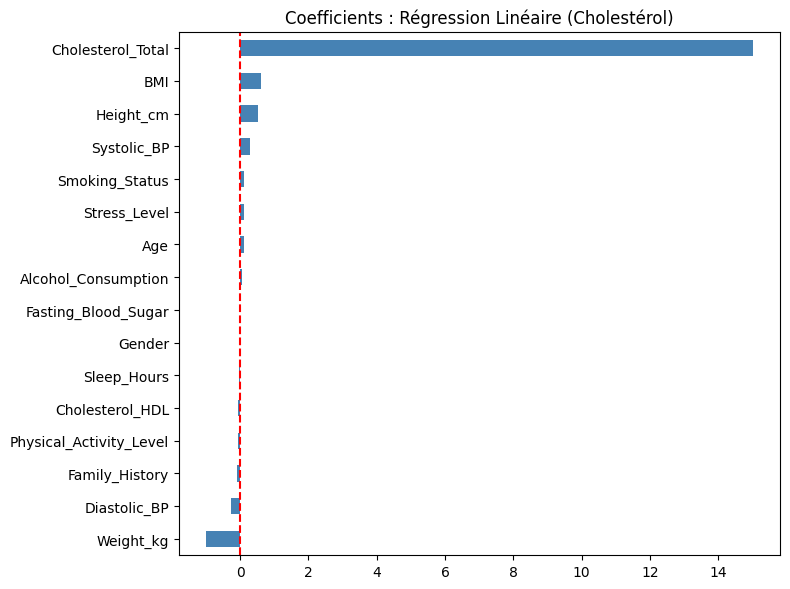

In [86]:
# Récupérer les coefficients du modèle entraîné
coef_chol = pd.Series(LM_Chol.coef_, index=X_chol.columns)

# Trier et tracer
coef_chol.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
print(coef_chol)
plt.title("Coefficients : Régression Linéaire (Cholestérol)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

#### Question ?
A revoir la logique des coefficients puisque Weight est corrélé positviement avec Chlo_LDL donc le coefficient doit etre positif non.

Le graphe des coefficients révèle une forte disparité entre les variables.`Cholesterol_Total` domine très largement avec un coefficient d'environ 15, ce qui est cohérent avec la matrice de corrélation établie lors de l'analyse exploratoire qui montrait déjà la corrélation la plus forte entre ces deux variables. Les autres variables ont des coefficients proches de zéro. On note cependant que `Weight_kg` présente un coefficient négatif alors que sa corrélation avec `Cholesterol_LDL` était positive; ceci s'explique par la multicolinéarité avec `BMI`, deux variables très fortement corrélées entre elles, ce qui pousse le modèle à leur attribuer des signes opposés pour éviter de compter deux fois le même effet.



##### Pénalisation Lasso L1
On applique maintenant une pénalisation **Lasso (L1)** sur la régression linéaire.
L'objectif est double : réduire le sur-apprentissage et effectuer une **sélection 
automatique de variables** en poussant certains coefficients exactement à zéro.

Dans un premier temps on utilise l'**alpha par défaut** (alpha=1) pour observer 
l'effet de la pénalisation, puis on optimisera alpha par validation croisée.

MSE = 101.76984582691672
R2  = 0.663516469239062

Variables éliminées  : 15
Variables conservées : 1


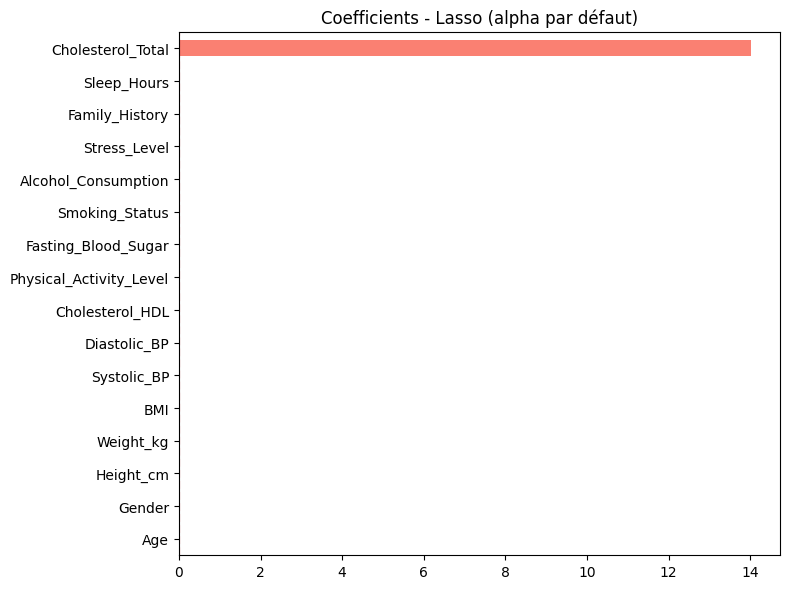

In [ ]:
from sklearn import linear_model

# Initialisation du modele Lasso ( par défaut alpha = 1)
regLasso_chol = linear_model.Lasso()
regLasso_chol.fit(Xr_train_chol, y_train_chol)

#  Réalisation de la prédiction
prev_chol = regLasso_chol.predict(Xr_test_chol)

# Pérformances 
print("MSE =", mean_squared_error(y_test_chol, prev_chol))
print("R2  =", r2_score(y_test_chol, prev_chol))

# Récupération des coefficients
coef_lasso_chol = pd.Series(regLasso_chol.coef_, index=X_chol.columns)
print(f"\nVariables éliminées  : {sum(coef_lasso_chol == 0)}")
print(f"Variables conservées : {sum(coef_lasso_chol != 0)}")

# Affichage des coefficients
coef_lasso_chol.sort_values().plot(kind='barh', figsize=(8, 6), color='salmon')
plt.title("Coefficients - Lasso (alpha par défaut)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Avec l'alpha par défaut la pénalisation est forte, presque toutes les variables sont réduites à zéro à l'exception de `Cholesterol_Total` qui conserve un coefficient d'environ 14. Cela confirme ce qu'on observait déjà dans le modèle simple : `Cholesterol_Total` est la seule variable suffisamment informative pour résister à la pénalisation. Ce résultat illustre bien le comportement du Lasso, il opère une sélection agressive et ne retient que l'essentiel. L'alpha par défaut reste cependant trop fort pour capturer les contributions plus subtiles des autres variables.

In [ ]:
from sklearn.model_selection import GridSearchCV

param = [{"alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1]}]

# Optimisation par validation croisée
regLasso_opt = GridSearchCV(linear_model.Lasso(max_iter=10000),
                             param, cv=10, n_jobs=-1)
regLassoOpt_chol = regLasso_opt.fit(Xr_train_chol, y_train_chol)

print("Meilleur R2    =", round(regLassoOpt_chol.best_score_, 4))
print("Meilleur alpha =", regLassoOpt_chol.best_params_)

# Prédiction
prev_chol_opt = regLassoOpt_chol.predict(Xr_test_chol)

print("MSE =", round(mean_squared_error(y_test_chol, prev_chol_opt), 4))
print("R2  =", round(r2_score(y_test_chol, prev_chol_opt), 4))

Meilleur R2    = 0.6936
Meilleur alpha = {'alpha': 0.2}
MSE = 101.3843
R2  = 0.6648


Le Lasso optimisé par validation croisée trouve un alpha optimal = 0.2, une pénalisation modérée qui conserve les variables les plus informatives tout en éliminant les moins pertinentes.

| Modèle | MSE Test | R² Test |
|---|---|---|
| Régression linéaire (MCO) | 101.62 | 0.664 |
| Lasso (alpha=0.2) | 101.38 | 0.665 |

Les performances sont quasi identiques au modèle MCO, le Lasso n'apporte pas d'amélioration significative en termes de R², ce qui suggère que la structure linéaire du modèle est le vrai facteur limitant, pas le nombre de variables.

Variables éliminées  : 14
Variables conservées : 2
Détails des variables conservées : 
 Cholesterol_Total    14.828848
Age                   0.003424
dtype: float64


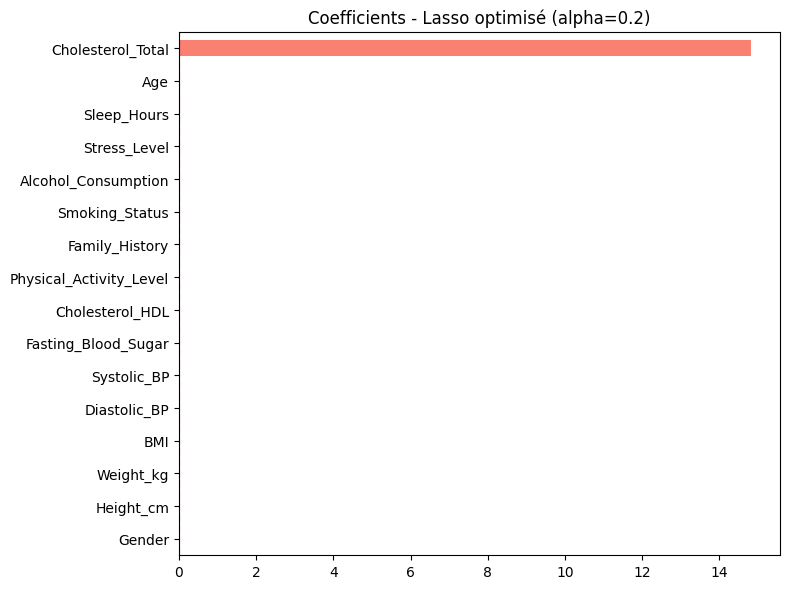

In [109]:
#  Ré-estimation avec alpha optimal pour afficher les coefficients 
regLasso_final = linear_model.Lasso(
    alpha=regLassoOpt_chol.best_params_['alpha'], 
    max_iter=10000)
regLasso_final.fit(Xr_train_chol, y_train_chol)

coef_lasso_opt = pd.Series(regLasso_final.coef_, index=X_chol.columns)
print(f"Variables éliminées  : {sum(coef_lasso_opt == 0)}")
print(f"Variables conservées : {sum(coef_lasso_opt != 0)}")

# Affichage des variables ayant des coefficients non nulls
non_zero_coefs = coef_lasso_opt[coef_lasso_opt != 0]


print("Détails des variables conservées : \n",non_zero_coefs.sort_values(ascending=False))

# Graphique pour les coefficients
coef_lasso_opt.sort_values().plot(kind='barh', figsize=(8, 6), color='salmon')
plt.title(f"Coefficients - Lasso optimisé (alpha={regLassoOpt_chol.best_params_['alpha']})")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Avec l'alpha optimal ( alpha = 0.2), le Lasso est beaucoup plus sélectif, il élimine **14 variables sur 16** et ne conserve que `Cholesterol_Total` et `Age`. Ce résultat est frappant mais cohérent : `Cholesterol_Total` domine largement, tandis que `Age` contribue de façon marginale (0.003). Toutes les autres variables sont jugées insuffisamment informatives 
par rapport à la pénalisation imposée. Cela confirme que dans un cadre linéaire, `Cholesterol_Total` concentre à lui seul l'essentiel de l'information prédictive sur `Cholesterol_LDL`.

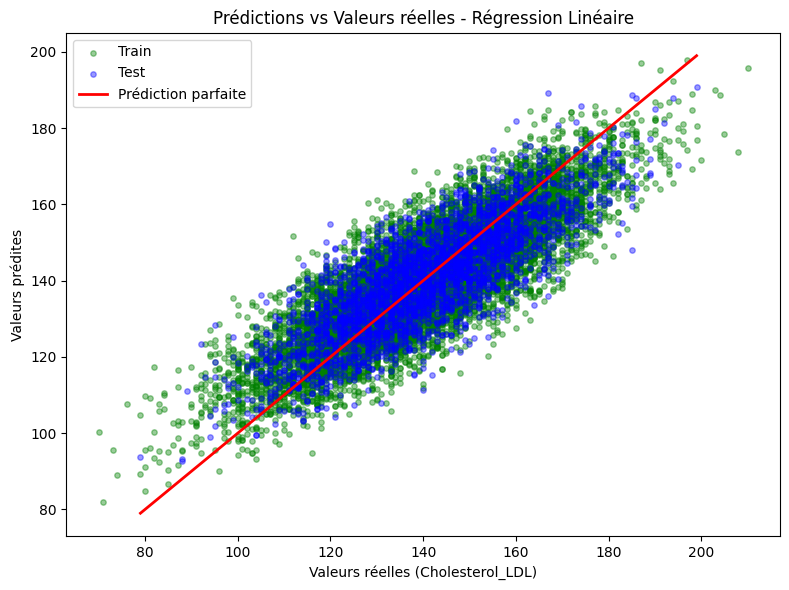

In [98]:
y_test_num  = y_test_chol.astype(float)
y_train_num = y_train_chol.astype(float)

plt.figure(figsize=(8, 6))
plt.scatter(y_train_num, LM_Chol.predict(Xr_train_chol),
            alpha=0.4, color='green', s=15, label='Train')
plt.scatter(y_test_num, y_pred_chol_test,
            alpha=0.4, color='blue', s=15, label='Test')

min_val = float(y_test_num.min())
max_val = float(y_test_num.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', lw=2, label='Prédiction parfaite')

plt.xlabel("Valeurs réelles (Cholesterol_LDL)")
plt.ylabel("Valeurs prédites")
plt.title("Prédictions vs Valeurs réelles - Régression Linéaire")
plt.legend()
plt.tight_layout()
plt.show()